In [1]:
import os
import glob
import copy
import re
import itertools
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

import networkx as nx
import kmapper as km
import utils
from importlib import reload
import matplotlib as mpl

In [2]:
fs = 12
src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep

p = re.compile('(.*)_B(.*)_Ov(.*)_dbscan(.*)')
# List the name of the lines, their repetitions
# and pairs to compare
reps = [1,2]
lines = ['BA24','BM24','IA24','IM24','ZA24','ZM24']
full_lines = list(itertools.chain(*[[ '{}_{}'.format(l,r) for r in reps ] for l in lines]))
comparisons = [(0,1),(2,3),(4,5),(0,2),(0,4),(1,3),(1,5)]

# Read the count number file
filename = src + 'readCounts_Xa7_msu_v7.csv'
data = pd.read_csv(filename).set_index('Geneid')
rpk = data[full_lines].div(data['Length'], axis='index')
print('Original dataframe dimensions:\t', rpk.shape)

# Standardize expression levels
# Remove genes where at least one population reports all zero values
tpm = utils.count_normalization(data[full_lines], rpk, lines, reps, normalize_flag='DESeq2')
print('After initial cleanup:\t', tpm.shape)

# Get all the foldchange values
# One per pair comparison
fcs = pd.DataFrame(np.nan, index=tpm.index, columns = ['{} vs {}'.format(lines[comp[0]],lines[comp[1]]) for comp in comparisons])
for comp in comparisons:
    key = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    fcs[key] = utils.foldchange(comp, rpk, tpm, lines, reps, alpha=1e-3)

fc = fcs.sum(axis=1)
lfc = np.log10(fc)

# For visualization purposes, remove the
# influence of outliers in the coloring
alpha = 0.001
mini, maxi = np.quantile(lfc, [alpha, 1-alpha])
chopped_lfc = lfc.copy()
chopped_lfc[chopped_lfc < mini] = mini
chopped_lfc[chopped_lfc > maxi] = maxi

lens = lfc.values.copy()
nlabels = ['min', 'mean', 'max', 'median', 'std', 'size', 'sqrtsize', 'cbrtsize']

tpm.head().round(0).astype(int)

Original dataframe dimensions:	 (55986, 12)
After initial cleanup:	 (24498, 12)


,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2
Geneid,,,,,,,,,,,,
LOC_Os01g01010,1935,1993,2965,1931,1997,1563,2227,2456,1780,1428,2486,2316
LOC_Os01g01030,98,86,112,121,153,134,93,202,98,159,175,220
LOC_Os01g01040,1465,1045,1698,1672,1420,1437,1407,1676,1287,1271,1385,1497
LOC_Os01g01050,1105,1129,1795,1652,1181,1127,1339,1547,1127,860,1494,1561
LOC_Os01g01060,4721,3802,3327,3661,3608,5367,3347,2783,4667,5143,2897,2991


In [44]:
filename = dst + 'log_isolation+sd_B110_Ov30_dbscan0,4.html'
bname = os.path.splitext(os.path.split(filename)[1])[0]
filters, binno, overlap, dbscan = p.findall(bname)[0]
filters = filters.replace('_',' ').replace('+',' & ').title().replace('Sd','SD')
dbscan = dbscan.replace(',','.')
overlap += '%'
print(filters, binno, overlap, dbscan, sep='\t')
mtitle = f'Filters: {filters}, Bins#: {binno}, Overlap: {overlap}, DBSCAN($\\varepsilon$): {dbscan}'

with open(filename, encoding="utf-8") as f:
    jdict = utils.html2json(f.read())
graph = utils.json2mapperG(jdict)

metanode = pd.DataFrame(np.nan, index=graph['nodes'].keys(), columns=nlabels)
for key in metanode.index:
    nn = lens[ graph['nodes'][key] ]
    for attr in nlabels[:5]:
        metanode.loc[key, attr] = getattr( np, attr)(nn)
    metanode.loc[key, 'size'] = len(nn)

metanode['sqrtsize'] = np.sqrt(metanode['size'])
metanode['cbrtsize'] = np.cbrt(metanode['size'])

In [45]:
G = utils.mapper2networkx(graph)
Gcpy = G.copy()

nG = list(G.nodes)
weights = [None] + list(list(G.edges(data=True))[0][-1].keys())[1:]

In [46]:
S = [G.subgraph(c).copy() for c in sorted(nx.connected_components(G), key=len, reverse=True)]

nS = list(S[0].nodes)
lowest = metanode.loc[ nS , 'median'].idxmin()

columns = list(itertools.chain(*[[f'{m}_{str(w)}' for m in ['aspl','spath','ecc']] for w in weights]))
gmetrics = pd.DataFrame(index=nS, columns=columns)
for w in weights:
    gmetrics['ecc_'+str(w)] = pd.Series(nx.eccentricity(S[0], weight=w))[nS]
    gmetrics['spath_'+str(w)]= pd.Series(nx.shortest_path_length(S[0], source=lowest, weight=w))[nS]
    aspl = dict(nx.all_pairs_dijkstra_path_length(S[0], weight=w))
    aspl = pd.Series([ sum(aspl[key].values())/len(aspl) for key in aspl ], index=aspl.keys())
    gmetrics['aspl_'+str(w)] = aspl[nS]

furthest = gmetrics['spath_None'].idxmax()

In [47]:
zeroweight = 3

temp_edge = []
furthest = gmetrics['spath_invsize'].sort_values().index
for ix in range(1, len(S)):
    temp_edge.append( (furthest[-3*ix], list(S[ix].nodes)[0]) )
    Gcpy.add_edge(temp_edge[-1][0], temp_edge[-1][1], size=zeroweight)

pos = nx.spring_layout(Gcpy, seed=4, weight='size')
bfspos = nx.bfs_layout(Gcpy, lowest, scale=len(S)-ix, center=(0,0), align='vertical')
#pos = nx.kamada_kawai_layout(S[ix],  weight='size')
#pos = nx.spectral_layout(S[ix],  weight='size')
#pos = nx.forceatlas2_layout(S[ix], seed=4, weight='size')
#pos = nx.arf_layout(G, seed=4)

dfpos = pd.concat( (pd.DataFrame(pos, index=[0,1]), pd.DataFrame(bfspos, index=[2,3])) , axis='index')
dfpos = dfpos.T.loc[nG]

nx.set_edge_attributes(Gcpy, dict(zip(temp_edge, np.zeros(len(temp_edge)))), 'size')

width = np.array([ foo[2] for foo in  Gcpy.edges(data='size')])
drawkw = dict(G=Gcpy, node_size=0, width = 0.75*np.cbrt(width), 
              edge_color=width, edge_cmap=mpl.colormaps['Greys'], edge_vmin=-7, edge_vmax=7,
              with_labels=False, hide_ticks=True, font_size=6)
scatterkw = dict(s=20*metanode.loc[nG, 'cbrtsize'], cmap='viridis', ec='k', zorder=4)
stdvmax = metanode.loc[nG, 'std'].sort_values().iloc[-3]
lvmax = metanode.loc[nS, 'mean'].sort_values().iloc[-2]

posS = dict(zip(nS, [ pos[key] for key in nS ]))
drawSkw = copy.deepcopy(drawkw)
widthS = np.array([ foo[2] for foo in  S[0].edges(data='size')])
drawSkw['G'] = S[0]
drawSkw['width'] = 0.75*np.cbrt(widthS)
drawSkw['edge_color'] = widthS
scatterSkw = dict(x=dfpos.loc[nS, 0], y=dfpos.loc[nS, 1], s=20*metanode.loc[nS, 'cbrtsize'], cmap='viridis', ec='k', zorder=4)

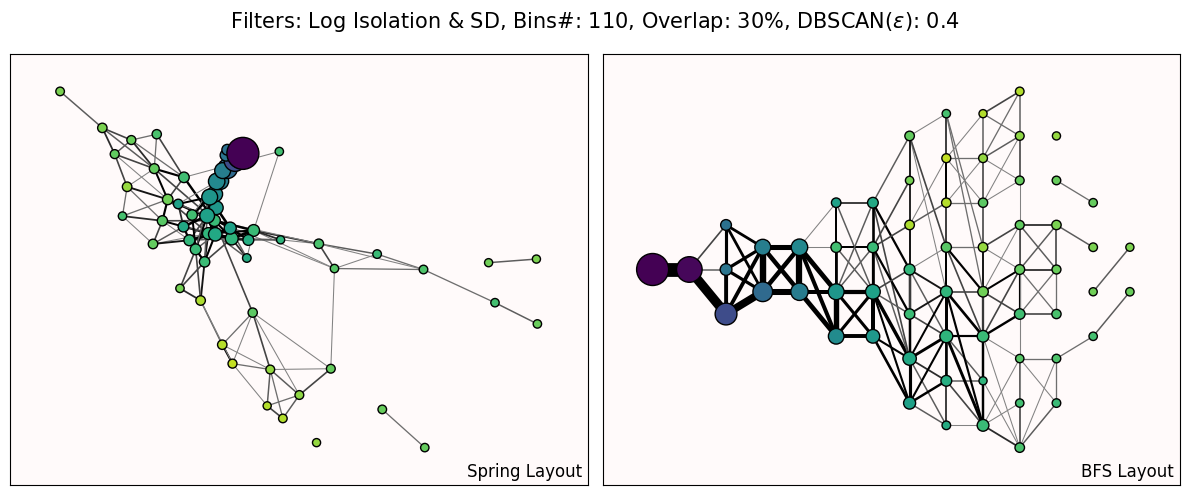

In [119]:
fig, ax = plt.subplots(1,2, figsize=(12,5)); i = 0

nx.draw_networkx(pos=pos, ax=ax[i], **drawkw )
ax[i].scatter(dfpos[0], dfpos[1] , c=metanode.loc[nG, 'median'], vmin=0, vmax=lvmax, label='LFC', **scatterkw)
ax[i].text(0.99, 0.01, 'Spring Layout', transform=ax[i].transAxes, fontsize=fs, ha='right', va='bottom')
i += 1
nx.draw_networkx(pos=bfspos, ax=ax[i], **drawkw )
ax[i].scatter(dfpos[2], dfpos[3] , c=metanode.loc[nG, 'median'], vmin=0, vmax=lvmax, label='LFC', **scatterkw)
ax[i].text(0.99, 0.01, 'BFS Layout', transform=ax[i].transAxes, fontsize=fs, ha='right', va='bottom')

for a in ax.ravel():
    a.set_facecolor('snow')
    #a.legend(loc='upper right', fontsize=fs)
fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

# Match genes to "strandiness"

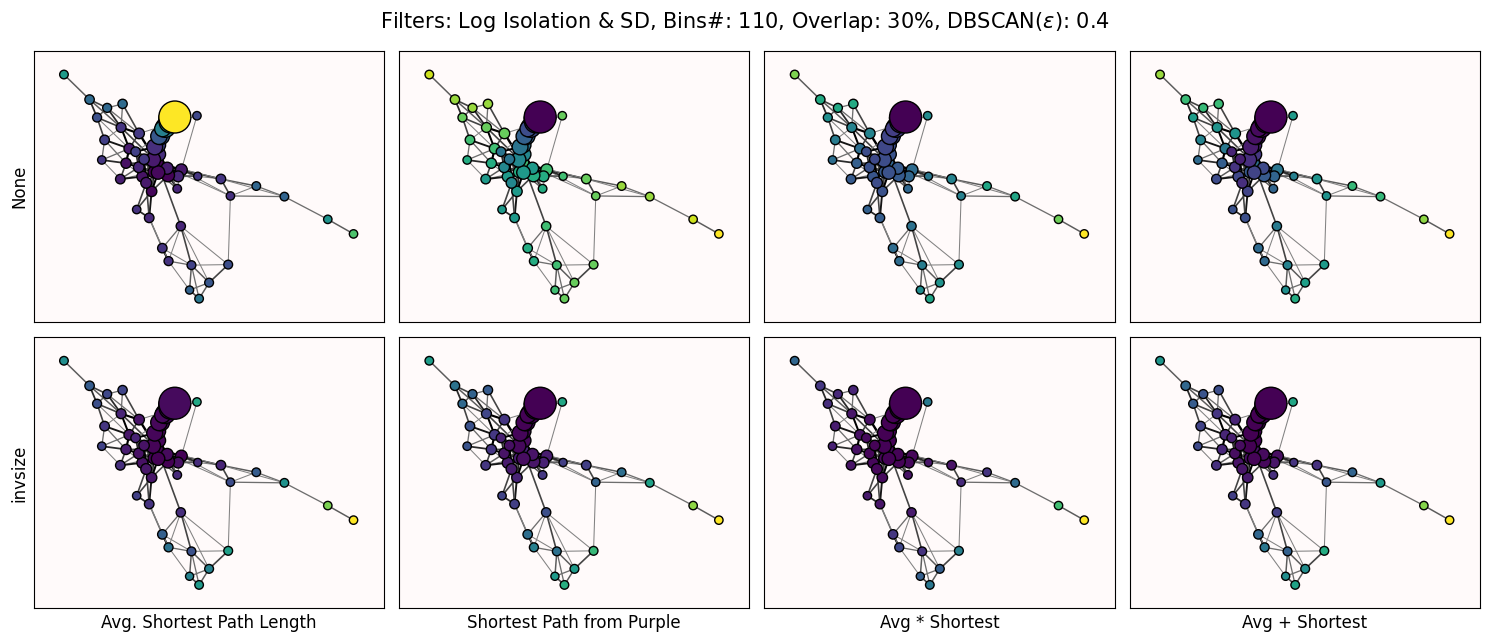

In [120]:
titles = ['Avg. Shortest Path Length', 'Shortest Path from Purple', 'Avg * Shortest', 'Avg + Shortest']
fig, ax = plt.subplots(2, 4, figsize=(15,6.5), sharex=True, sharey=True)

for a in ax.ravel():
    nx.draw_networkx(pos=posS, ax=a, **drawSkw )
    a.set_facecolor('snow')

for i,w in enumerate([None, 'invsize']):
    ax[i,0].set_ylabel(str(w), fontsize=fs)
    ax[i,0].scatter(c=gmetrics.loc[nS, 'aspl_'+str(w)], **scatterSkw)
    ax[i,1].scatter(c=gmetrics.loc[nS, 'spath_'+str(w)], **scatterSkw)
    ax[i,2].scatter(c=gmetrics.loc[nS, 'aspl_'+str(w)] * gmetrics.loc[nS, 'spath_'+str(w)], **scatterSkw)
    ax[i,3].scatter(c=gmetrics.loc[nS, 'aspl_'+str(w)] + gmetrics.loc[nS, 'spath_'+str(w)], **scatterSkw)

for i in range(len(titles)):
    ax[1,i].set_xlabel(titles[i], fontsize=fs)
fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

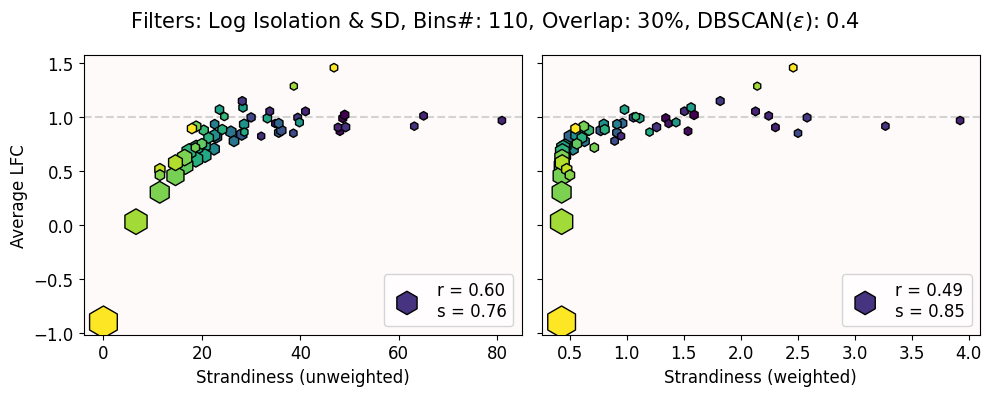

In [121]:
LFC = metanode.loc[nS, 'mean']

w = 'invsize'; strand0 = gmetrics['aspl_'+str(w)] + gmetrics['spath_'+str(w)]
w = None; strand1 = gmetrics['aspl_'+str(w)] * gmetrics['spath_'+str(w)]
fig, ax = plt.subplots(1,2, figsize=(10,4), sharey=True); i = 0
for w,strand in zip(['unweighted','weighted'], [strand1,strand0]):
    
    spearman = stats.spearmanr(strand, LFC)
    pearson = stats.pearsonr(strand, LFC)
    label = 'r = {:.2f}\ns = {:.2f}'.format(pearson.statistic,spearman.statistic)
    ax[i].axhline(1, c='lightgray', ls='dashed', zorder=1)
    ax[i].scatter(strand, LFC, s=scatterSkw['s'], c=metanode.loc[nS,'std'], marker='h', ec='k', vmax=stdvmax, label=label, zorder=4 )
    ax[i].set_xlabel('Strandiness (' + str(w) + ')', fontsize=fs)
    ax[i].tick_params(labelsize = fs)
    ax[i].set_facecolor('snow')
    ax[i].legend(loc='lower right', fontsize=fs)
    i += 1

fig.suptitle(mtitle, fontsize=1.25*fs)
ax[0].set_ylabel('Average LFC', fontsize=fs)
fig.tight_layout()

# Different clusters highlight different sample pair comparisons (?)

In [52]:
metanodes = dict()
for comp in comparisons:
    dkey = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    LFC = np.log10(fcs[dkey].copy())
    meta = pd.DataFrame(np.nan, index=graph['nodes'].keys(), columns=nlabels[:5])
    for key in meta.index:
        nn = LFC.iloc[ graph['nodes'][key] ]
        for attr in meta.columns:
            meta.loc[key, attr] = getattr( np, attr)(nn)
        
    mini, maxi = np.quantile( LFC , [alpha, 1-alpha])
    LFC[LFC < mini] = mini
    LFC[LFC > maxi] = maxi
    
    metanodes[dkey] = meta

metavmax = dict()
for comp in comparisons:
    dkey = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    metavmax[dkey] = metanodes[dkey]['mean'].sort_values().iloc[-2]

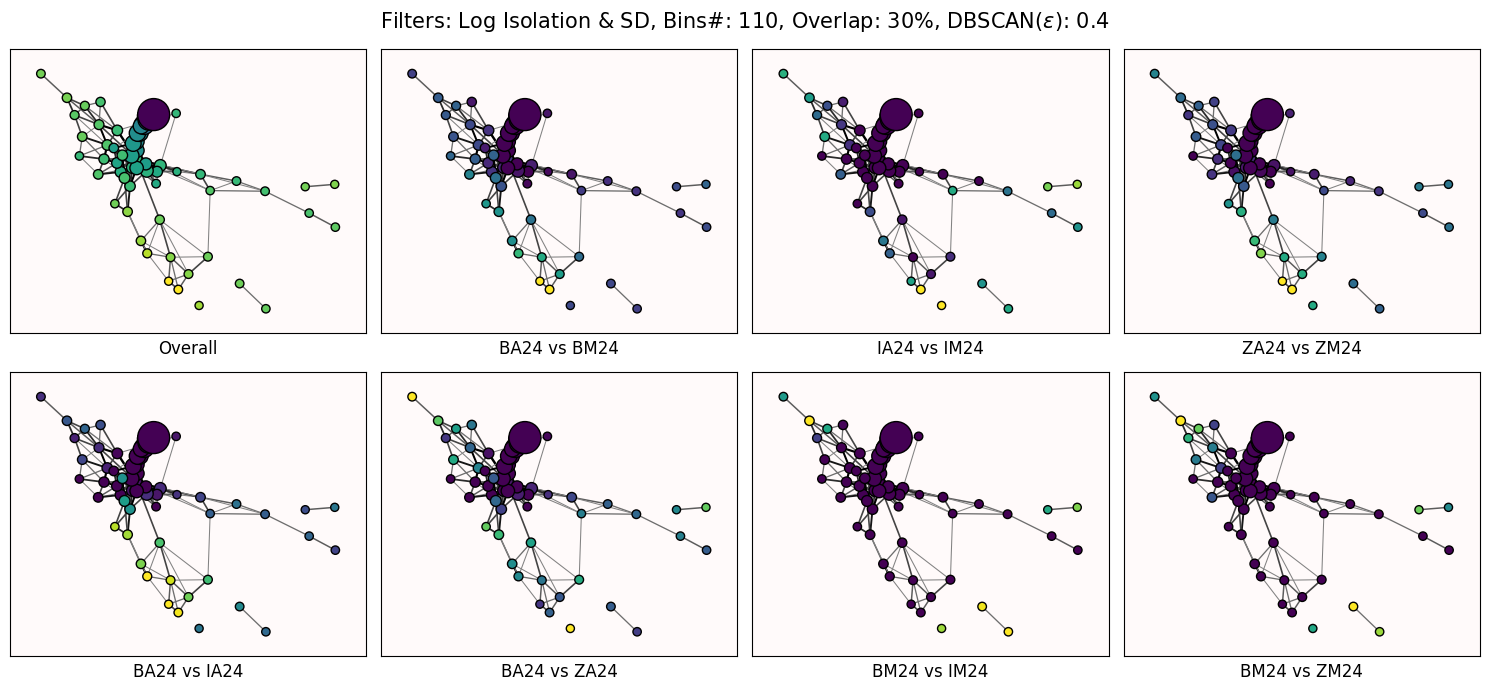

In [122]:
fig, ax = plt.subplots(2, 4, figsize=(15,7))
ax = ax.ravel(); i = 0

for a in ax:
    a.set_facecolor('snow')
    nx.draw_networkx(pos=pos, ax=a, **drawkw )
ax[i].scatter(dfpos[0], dfpos[1] , c=metanode.loc[nG, 'mean'], vmin=0, vmax=lvmax, **scatterkw)
ax[i].set_xlabel('Overall sum', fontsize=fs)
for comp in comparisons:
    i += 1
    key = '{} vs {}'.format(lines[comp[0]],lines[comp[1]])
    ax[i].scatter(dfpos[0], dfpos[1] , c=metanodes[key].loc[nG, 'mean'], vmin=0, vmax=metavmax[key], **scatterkw)
    ax[i].set_xlabel(key, fontsize=fs)

fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();

# What genes are in what cluster

In [19]:
metanode.sort_values(by='mean', ascending=False).head(10)

,min,mean,max,median,std,size,sqrtsize,cbrtsize
cube309_cluster1,0.965367,1.172251,1.289952,1.174865,0.102985,11.0,3.316625,2.223980
cube280_cluster0,0.950728,1.130249,1.289952,1.130446,0.131124,6.0,2.449490,1.817121
cube299_cluster1,0.965367,1.126866,1.267448,1.145500,0.098207,10.0,3.162278,2.154435
cube291_cluster0,0.966708,1.100123,1.289952,1.112476,0.116476,5.0,2.236068,1.709976
cube255_cluster0,0.997836,1.074444,1.141418,1.084777,0.046347,5.0,2.236068,1.709976
cube290_cluster1,0.953926,1.052209,1.122628,1.063393,0.061629,7.0,2.645751,1.912931
cube308_cluster1,0.569006,1.046640,1.289952,1.085267,0.202042,18.0,4.242641,2.620741
cube309_cluster0,0.902192,1.034034,1.111325,1.046145,0.063709,6.0,2.449490,1.817121
cube279_cluster1,0.956592,1.023820,1.100977,1.011005,0.060594,6.0,2.449490,1.817121
cube209_cluster0,0.998511,1.020387,1.035460,1.022273,0.013162,6.0,2.449490,1.817121


In [27]:
key = 'cube280_cluster0'
fcs.iloc[graph['nodes'][key] ]

,BA24 vs BM24,IA24 vs IM24,ZA24 vs ZM24,BA24 vs IA24,BA24 vs ZA24,BM24 vs IM24,BM24 vs ZM24
Geneid,,,,,,,
LOC_Os03g12500,3.116607,0.637461,5.534109,2.395388,1.130130,0.395855,0.642316
LOC_Os03g15780,2.831900,1.005882,2.978721,1.514798,1.022459,0.194298,0.223693
LOC_Os10g39260,2.674730,0.928095,5.041982,1.484469,1.210546,0.890417,0.933612
LOC_Os11g31190,519.403220,25.389856,113.101222,1.294466,1.227578,0.022151,0.016789
LOC_Os01g50100,1.967071,0.598093,2.597324,1.963723,1.117151,0.303027,0.381069
LOC_Os02g36110,14.417998,2.287954,14.300413,2.382627,1.034944,0.072519,0.076683


In [28]:
tpm.iloc[ graph['nodes'][key] ]

,BA24_1,BA24_2,BM24_1,BM24_2,IA24_1,IA24_2,IM24_1,IM24_2,ZA24_1,ZA24_2,ZM24_1,ZM24_2
Geneid,,,,,,,,,,,,
LOC_Os03g12500,26857.338843,25013.701913,4336.769755,11318.370675,7157.256412,14497.291444,6449.773683,2411.411203,18691.549109,27206.742431,1717.253479,1922.476962
LOC_Os03g15780,25358.782866,26119.037997,6543.508291,4654.052589,15873.722778,18109.561044,3261.376387,5363.382133,22025.433195,30608.544840,3789.093428,3910.091091
LOC_Os10g39260,29461.953642,24472.666312,4802.149303,15362.363907,6083.105136,30249.484975,17748.475386,11137.054248,21193.659260,23360.287501,1861.823169,4076.963208
LOC_Os11g31190,23470.023894,17008.560260,14.967281,21.940142,13204.038428,18066.447456,189.351154,102.963758,21848.858988,27841.761541,119.172312,104.219467
LOC_Os01g50100,30830.124954,33427.498717,10751.185244,9847.009912,16001.221690,16721.118095,4244.621702,5971.897941,26638.461172,30880.756206,3149.206490,3730.963882
LOC_Os02g36110,24964.658233,26246.627622,967.728281,1309.552216,8667.328415,12826.292243,932.948915,687.283082,19281.774678,30200.395724,668.390610,973.335384
